In [14]:
import pandas as pd

# Column names (41 features + label)
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label",
    "difficulty_level" 
]

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/hemachander002/kdd-nsl/KDDTrain+.txt", names=columns)

print(df.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [15]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [16]:
df['label'].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [18]:
df['protocol_type'].value_counts()

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

In [19]:
df['service'].value_counts()


service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64

In [20]:
df['flag'].value_counts()

flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64

In [21]:
for col in df.columns:
    print(f"column : {col}")
    print(df[col].unique())
    print()
    

column : duration
[    0  5607   507 ...  5430 11680   679]

column : protocol_type
['tcp' 'udp' 'icmp']

column : service
['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

column : flag
['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']

column : src_bytes
[  491   146     0 ...  2816 11466  2358]

column : dst_bytes
[    0  8153   420 ...  5424 17655 52866]

column : land
[0 1]

column : wrong_fragment
[0 3 

In [22]:
df['label'] = df['label'].str.strip()  # remove spaces

df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

In [23]:
x = df.drop('label', axis=1)
y = df['label']

In [24]:
x = pd.get_dummies(x, columns=['protocol_type','service','flag'])

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [26]:
from sklearn.ensemble import IsolationForest
ifm = IsolationForest(contamination=0.1, random_state=42)
ifm.fit(x_scaled)

IsolationForest(contamination=0.1, random_state=42)

In [27]:
ifmpreds = ifm.predict(x_scaled)
ifmpreds = [1 if x == -1 else 0 for x in ifmpreds]

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y, ifmpreds))

              precision    recall  f1-score   support

           0       0.56      0.94      0.70     67343
           1       0.70      0.15      0.25     58630

    accuracy                           0.57    125973
   macro avg       0.63      0.55      0.48    125973
weighted avg       0.63      0.57      0.49    125973



In [29]:
for c in [0.05, 0.1, 0.2, 0.3]:
    model = IsolationForest(contamination=c, random_state=42)
    model.fit(x_scaled)
    
    preds = model.predict(x_scaled)
    preds = [1 if x == -1 else 0 for x in preds]
    
    print(f"Contamination: {c}")
    print(classification_report(y, preds))
    print()

Contamination: 0.05
              precision    recall  f1-score   support

           0       0.55      0.97      0.70     67343
           1       0.72      0.08      0.14     58630

    accuracy                           0.56    125973
   macro avg       0.63      0.53      0.42    125973
weighted avg       0.63      0.56      0.44    125973


Contamination: 0.1
              precision    recall  f1-score   support

           0       0.56      0.94      0.70     67343
           1       0.70      0.15      0.25     58630

    accuracy                           0.57    125973
   macro avg       0.63      0.55      0.48    125973
weighted avg       0.63      0.57      0.49    125973


Contamination: 0.2
              precision    recall  f1-score   support

           0       0.60      0.90      0.72     67343
           1       0.72      0.31      0.44     58630

    accuracy                           0.62    125973
   macro avg       0.66      0.60      0.58    125973
weighted avg  

In [30]:
x_normal = x_scaled[y == 0]
from sklearn.ensemble import IsolationForest

ifm2 = IsolationForest(contamination=0.3, random_state=42)
ifm2.fit(x_normal)

IsolationForest(contamination=0.3, random_state=42)

In [31]:
ifm2preds = ifm2.predict(x_scaled)
ifm2preds = [1 if x == -1 else 0 for x in ifm2preds]

In [32]:
print(classification_report(y, ifm2preds))

              precision    recall  f1-score   support

           0       1.00      0.70      0.82     67343
           1       0.74      1.00      0.85     58630

    accuracy                           0.84    125973
   macro avg       0.87      0.85      0.84    125973
weighted avg       0.88      0.84      0.84    125973



In [33]:
df_test = pd.read_csv("/kaggle/input/datasets/hemachander002/kdd-nsl/KDDTest+.txt", names=columns)

In [34]:
df_test['label'] = df_test['label'].str.strip()
df_test['label'] = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

In [35]:
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

In [36]:
X_test = pd.get_dummies(X_test, columns=['protocol_type','service','flag'])

In [37]:
X_test = X_test.reindex(columns=x.columns, fill_value=0)

In [38]:
X_test_scaled = scaler.transform(X_test)

In [39]:
ifm2preds = ifm2.predict(X_test_scaled)
ifm2preds = [1 if x == -1 else 0 for x in ifm2preds]

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, ifm2preds))

              precision    recall  f1-score   support

           0       0.92      0.80      0.85      9711
           1       0.86      0.95      0.90     12833

    accuracy                           0.88     22544
   macro avg       0.89      0.87      0.88     22544
weighted avg       0.88      0.88      0.88     22544



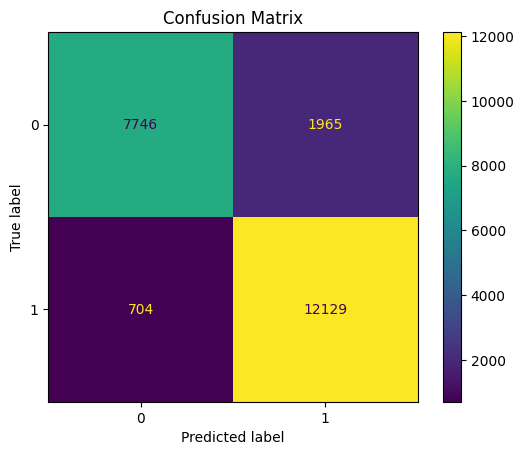

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, ifm2preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [42]:
scores = ifm2.decision_function(x_scaled)

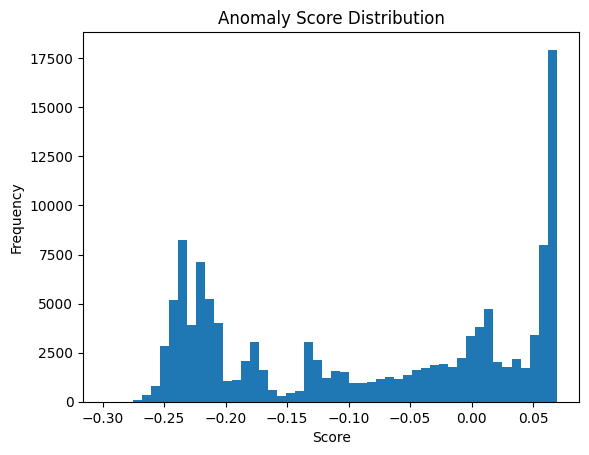

In [43]:
plt.hist(scores, bins=50)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [44]:
from sklearn.cluster import DBSCAN

db_model = DBSCAN(eps=3, min_samples=10)
db_preds = db_model.fit_predict(x_scaled)


db_preds = [1 if x == -1 else 0 for x in db_preds]

from sklearn.metrics import classification_report
print(classification_report(y, preds))

              precision    recall  f1-score   support

           0       0.64      0.83      0.72     67343
           1       0.70      0.45      0.55     58630

    accuracy                           0.66    125973
   macro avg       0.67      0.64      0.64    125973
weighted avg       0.67      0.66      0.64    125973



In [45]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.3, novelty=True)

lof.fit(x_normal)  # semi-supervised

lofpreds = lof.predict(x_scaled)
lofpreds = [1 if x == -1 else 0 for x in lofpreds]

print(classification_report(y, lofpreds))

              precision    recall  f1-score   support

           0       1.00      0.72      0.84     67343
           1       0.76      1.00      0.86     58630

    accuracy                           0.85    125973
   macro avg       0.88      0.86      0.85    125973
weighted avg       0.89      0.85      0.85    125973



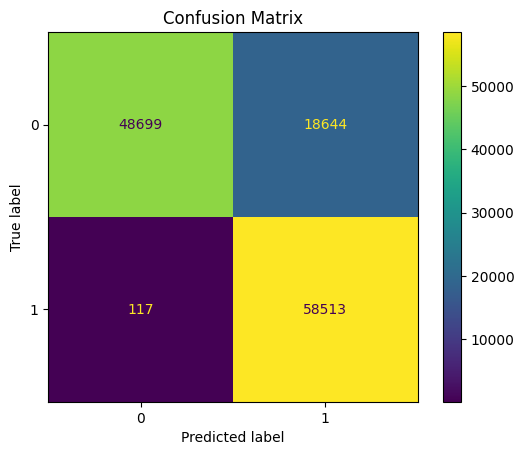

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y, lofpreds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [47]:
lofpreds = lof.predict(X_test_scaled)
lofpreds = [1 if x == -1 else 0 for x in lofpreds]

print(classification_report(y_test, lofpreds))

              precision    recall  f1-score   support

           0       0.99      0.60      0.74      9711
           1       0.76      0.99      0.86     12833

    accuracy                           0.82     22544
   macro avg       0.88      0.79      0.80     22544
weighted avg       0.86      0.82      0.81     22544



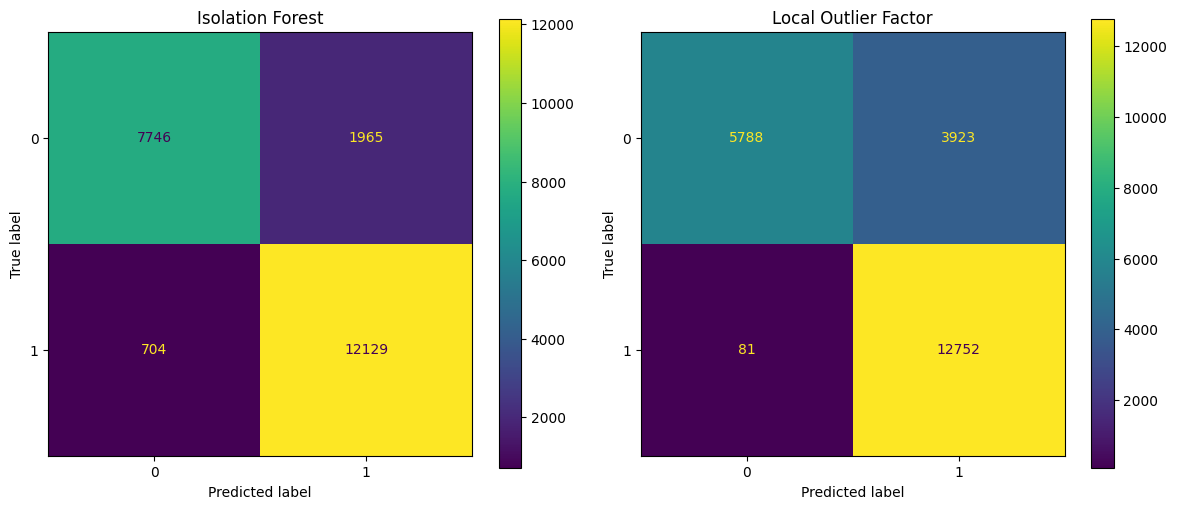

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

cmif = confusion_matrix(y_test, ifm2preds)
cmlof = confusion_matrix(y_test, lofpreds)


fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Isolation Forest
disp1 = ConfusionMatrixDisplay(confusion_matrix=cmif)
disp1.plot(ax=axes[0])
axes[0].set_title("Isolation Forest")

# LOF
disp2 = ConfusionMatrixDisplay(confusion_matrix=cmlof)
disp2.plot(ax=axes[1])
axes[1].set_title("Local Outlier Factor")

plt.tight_layout()
plt.show()

In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

In [50]:
import numpy as np
ifm2preds = np.array(ifm2preds)

In [51]:
normal = X_test_pca[ifm2preds == 0]
anomaly = X_test_pca[ifm2preds == 1]

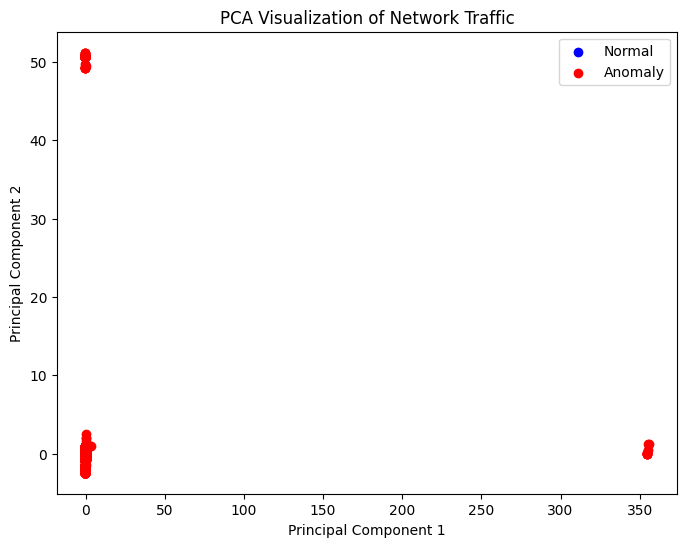

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(normal[:,0], normal[:,1], color = "blue", label="Normal")
plt.scatter(anomaly[:,0], anomaly[:,1], color = "red", label="Anomaly")

plt.title("PCA Visualization of Network Traffic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

In [53]:
print(X_test_pca.shape)
print(len(ifm2preds))
print(set(ifm2preds))

(22544, 2)
22544
{np.int64(0), np.int64(1)}


Running t-SNE (this may take time)...


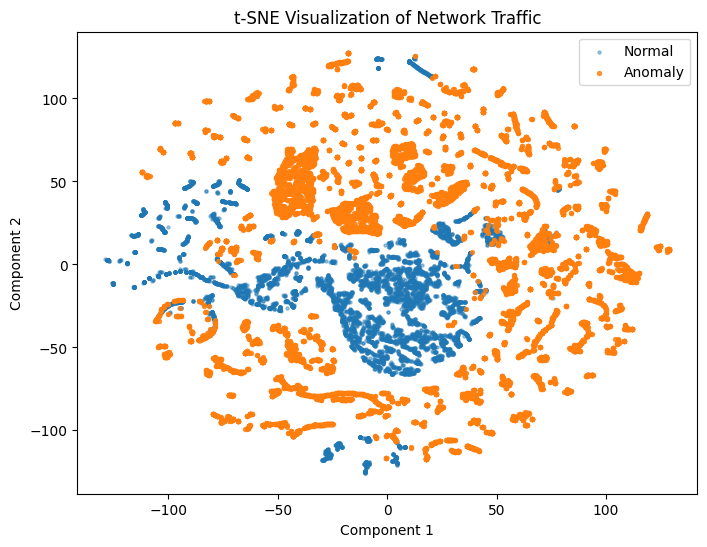

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Running t-SNE (this may take time)...")

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_test_scaled)

# Separate classes
normal_tsne = X_tsne[ifm2preds == 0]
anomaly_tsne = X_tsne[ifm2preds == 1]

# -----------------------------
# STEP 6: Plot t-SNE
# -----------------------------
plt.figure(figsize=(8,6))

plt.scatter(normal_tsne[:,0], normal_tsne[:,1], 
            s=5, alpha=0.4, label="Normal")

plt.scatter(anomaly_tsne[:,0], anomaly_tsne[:,1], 
            s=8, alpha=0.8, label="Anomaly")

plt.title("t-SNE Visualization of Network Traffic")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()

plt.show()

In [57]:
import joblib
joblib.dump(ifm2 , "anomaly_detection.pkl")

['anomaly_detection.pkl']